## **Name:** Rohan Khadye

## **Roll no:** 23102C0065

## **CMPN C**

# Social Network Analysis with R

This notebook is an R/Jupyter version of the **Social Network Analysis with R | Examples** program from the `bkrai/R-files-from-YouTube` repository.

It demonstrates graph creation, degree measures, diameter, density, reciprocity, closeness, betweenness, visualization, hub/authority scores, and community detection using `igraph`.


In [ ]:
# Install packages if they are not already installed
if (!requireNamespace("igraph", quietly = TRUE)) {
  install.packages("igraph", repos = "https://cloud.r-project.org")
}

library(igraph)
packageVersion("igraph")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




[1] ‘2.3.3’

## 1. Create a simple undirected network


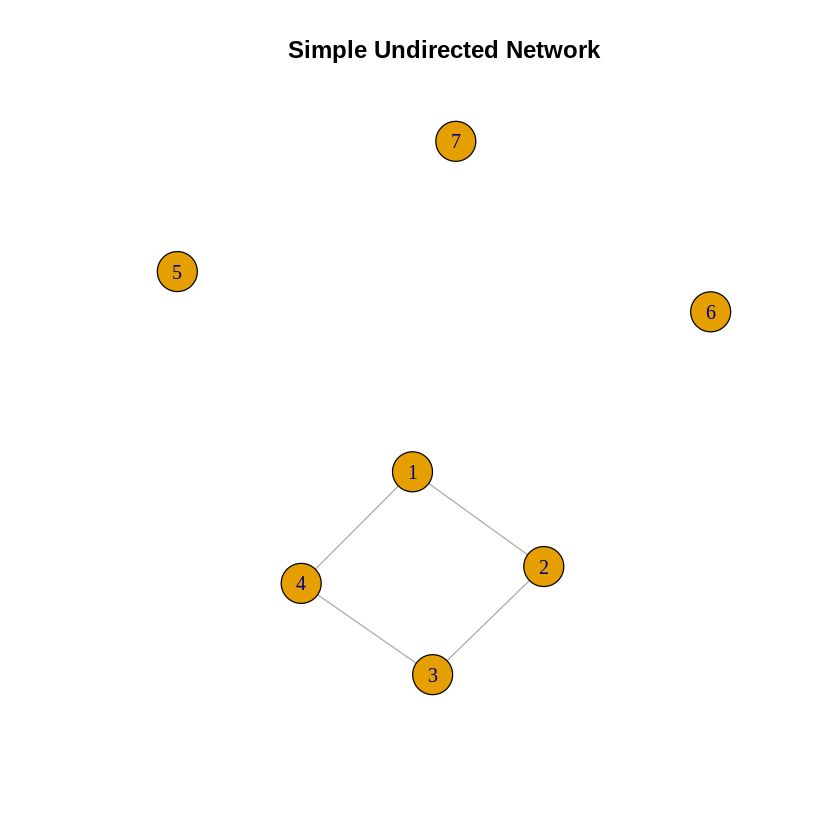

In [ ]:
g <- graph_from_edgelist(
  matrix(c(1,2, 2,3, 3,4, 4,1), ncol = 2, byrow = TRUE),
  directed = FALSE
)
g <- add_vertices(g, 3)

plot(g, main = "Simple Undirected Network")


## 2. Create a directed network with named vertices


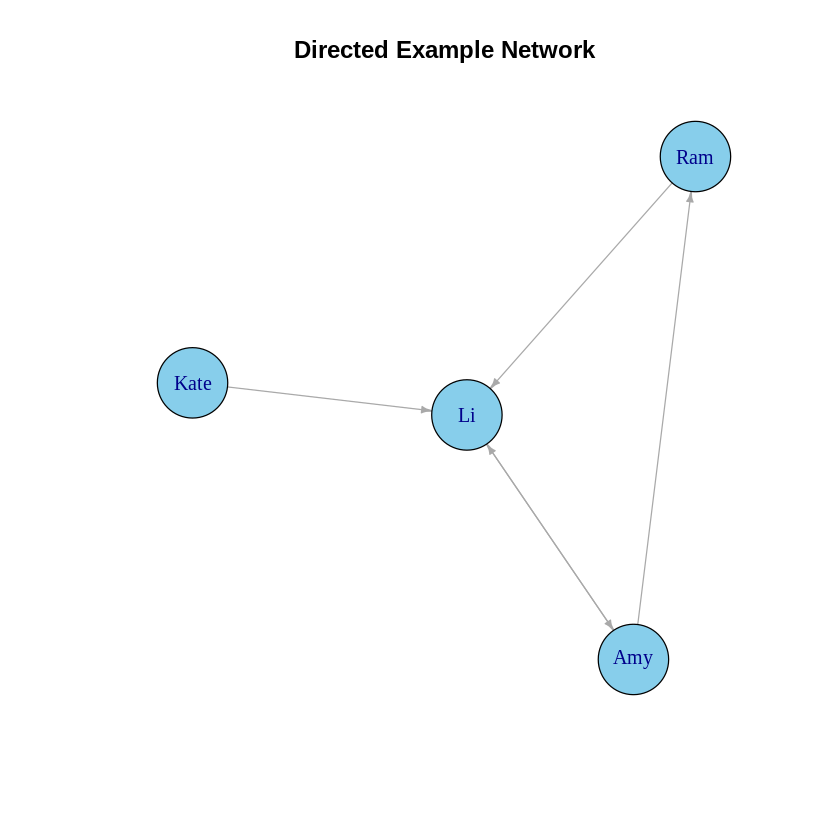

In [ ]:
g1 <- graph_from_edgelist(
  matrix(c(
    "Amy", "Ram",
    "Ram", "Li",
    "Li", "Amy",
    "Amy", "Li",
    "Kate", "Li"
  ), ncol = 2, byrow = TRUE),
  directed = TRUE
)

plot(g1, vertex.color = "skyblue", vertex.size = 28,
     edge.arrow.size = 0.4, main = "Directed Example Network")


## 3. Basic network measures


In [ ]:
cat("Degree (all):\n")
print(degree(g1, mode = "all"))

cat("\nIn-degree:\n")
print(degree(g1, mode = "in"))

cat("\nOut-degree:\n")
print(degree(g1, mode = "out"))

cat("\nDiameter:\n")
print(diameter(g1, directed = FALSE, weights = NA))

cat("\nEdge density:\n")
print(edge_density(g1, loops = FALSE))

cat("\nReciprocity:\n")
print(reciprocity(g1))

cat("\nCloseness:\n")
print(closeness(g1, mode = "all", weights = NA, normalized = TRUE))

cat("\nBetweenness:\n")
print(betweenness(g1, directed = TRUE, weights = NA, normalized = FALSE))

cat("\nEdge betweenness:\n")
print(edge_betweenness(g1, directed = TRUE, weights = NA))


Degree (all):
 Amy  Ram   Li Kate 
   3    2    4    1 

In-degree:
 Amy  Ram   Li Kate 
   1    1    3    0 

Out-degree:
 Amy  Ram   Li Kate 
   2    1    1    1 

Diameter:
[1] 2

Edge density:
[1] 0.4166667

Reciprocity:
[1] 0.4

Closeness:
 Amy  Ram   Li Kate 
0.75 0.75 1.00 0.60 

Betweenness:
 Amy  Ram   Li Kate 
   2    0    3    0 

Edge betweenness:
[1] 3 2 5 1 3


## 4. Load the repository network data

The original R program reads `networkdata.csv` from the repository. The dataset contains two columns representing the two endpoints of each relationship.

In [ ]:
data_url <- "https://raw.githubusercontent.com/bkrai/R-files-from-YouTube/main/networkdata.csv"
data <- read.csv(data_url, header = TRUE, stringsAsFactors = FALSE)

cat("Dataset dimensions:\n")
print(dim(data))

cat("\nColumn names:\n")
print(names(data))

cat("\nFirst rows:\n")
print(head(data))


Dataset dimensions:
[1] 290   4

Column names:
[1] "first"  "second" "grade"  "spec"  

First rows:
  first second grade spec
1    AA     DD     6    Y
2    AB     DD     6    R
3    AF     BA     6    Q
4    DD     DA     6    Q
5    CD     EC     6    X
6    DD     CE     6    Y


## 5. Prepare the edge list

The source program expects the columns `first` and `second`. The checks below make the notebook fail with a useful message if the downloaded data has a different structure.

In [ ]:
required_columns <- c("first", "second")
missing_columns <- setdiff(required_columns, names(data))

if (length(missing_columns) > 0) {
  stop(
    paste0(
      "Required column(s) missing: ",
      paste(missing_columns, collapse = ", ")
    )
  )
}

y <- data.frame(
  from = as.character(data$first),
  to = as.character(data$second),
  stringsAsFactors = FALSE
)

# Remove incomplete edges
y <- y[complete.cases(y) & y$from != "" & y$to != "", ]

head(y)


,from,to
,<chr>,<chr>
1,AA,DD
2,AB,DD
3,AF,BA
4,DD,DA
5,CD,EC
6,DD,CE


## 6. Create the social network


In [ ]:
net <- graph_from_data_frame(y, directed = TRUE)

V(net)$label <- V(net)$name
V(net)$degree <- degree(net, mode = "all")

cat("Number of nodes:", vcount(net), "\n")
cat("Number of edges:", ecount(net), "\n")


Number of nodes: 52 
Number of edges: 290 


## 7. Histogram of node degree


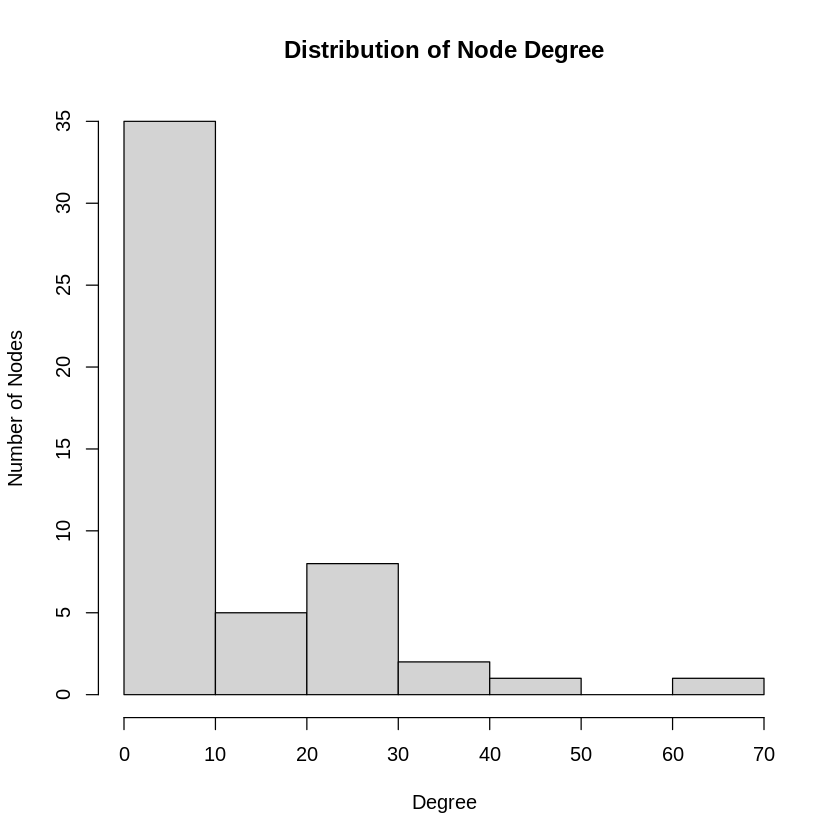

In [ ]:
hist(
  V(net)$degree,
  main = "Distribution of Node Degree",
  xlab = "Degree",
  ylab = "Number of Nodes"
)


## 8. Network diagram


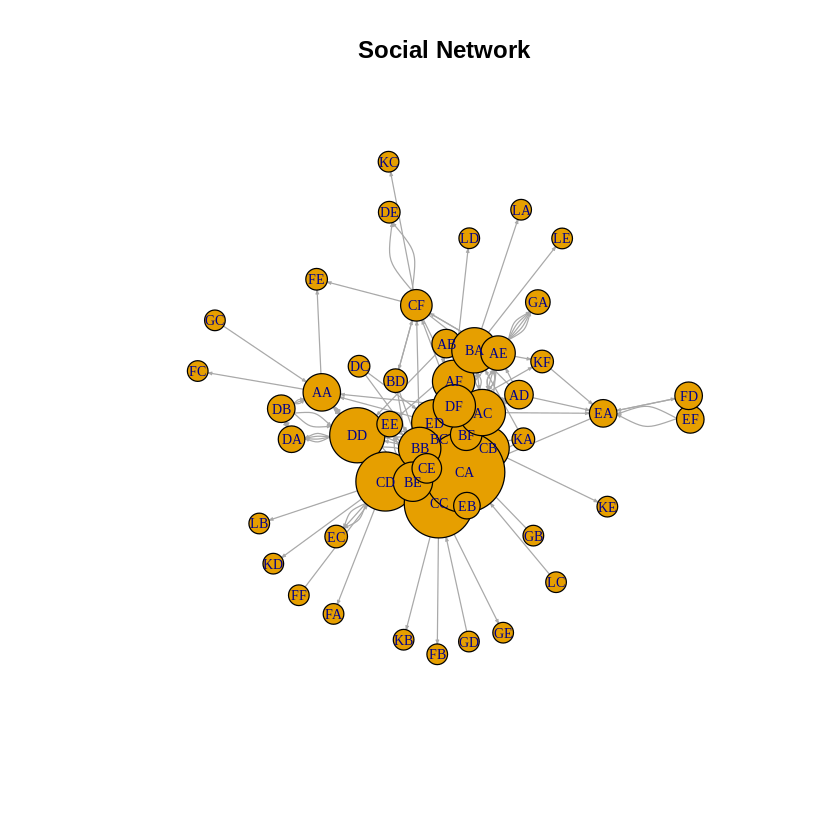

In [ ]:
set.seed(123)
plot(
  net,
  vertex.size = 8 + V(net)$degree * 0.4,
  vertex.label.cex = 0.7,
  edge.arrow.size = 0.15,
  layout = layout_with_fr(net),
  main = "Social Network"
)


## 9. Hub and authority scores

`hub_score()` identifies nodes that point to strong authorities, while `authority_score()` identifies nodes pointed to by strong hubs.

In [ ]:
hs <- hub_score(net)$vector
as <- authority_score(net)$vector

hub_table <- data.frame(
  node = V(net)$name,
  hub_score = as.numeric(hs)
)

authority_table <- data.frame(
  node = V(net)$name,
  authority_score = as.numeric(as)
)

cat("Top hub nodes:\n")
print(head(hub_table[order(-hub_table$hub_score), ], 10))

cat("\nTop authority nodes:\n")
print(head(authority_table[order(-authority_table$authority_score), ], 10))


Warning message:
“`hub_score()` was deprecated in igraph 2.0.3.
ℹ Please use `hits_scores()` instead.”
Warning message:
“`authority_score()` was deprecated in igraph 2.1.0.
ℹ Please use `hits_scores()` instead.”


Top hub nodes:
   node  hub_score
8    CC 1.00000000
7    CB 0.71458882
5    CD 0.23501653
9    BC 0.23218284
22   BE 0.21952715
16   AC 0.20935179
13   EB 0.18700581
14   BF 0.12723145
15   BB 0.11508082
1    AA 0.08042807

Top authority nodes:
   node authority_score
12   CA      1.00000000
21   DF      0.19256499
4    DD      0.14096985
8    CC      0.11219410
22   BE      0.10951546
3    AF      0.08375004
15   BB      0.08323026
5    CD      0.07894656
16   AC      0.06262068
10   ED      0.04799095


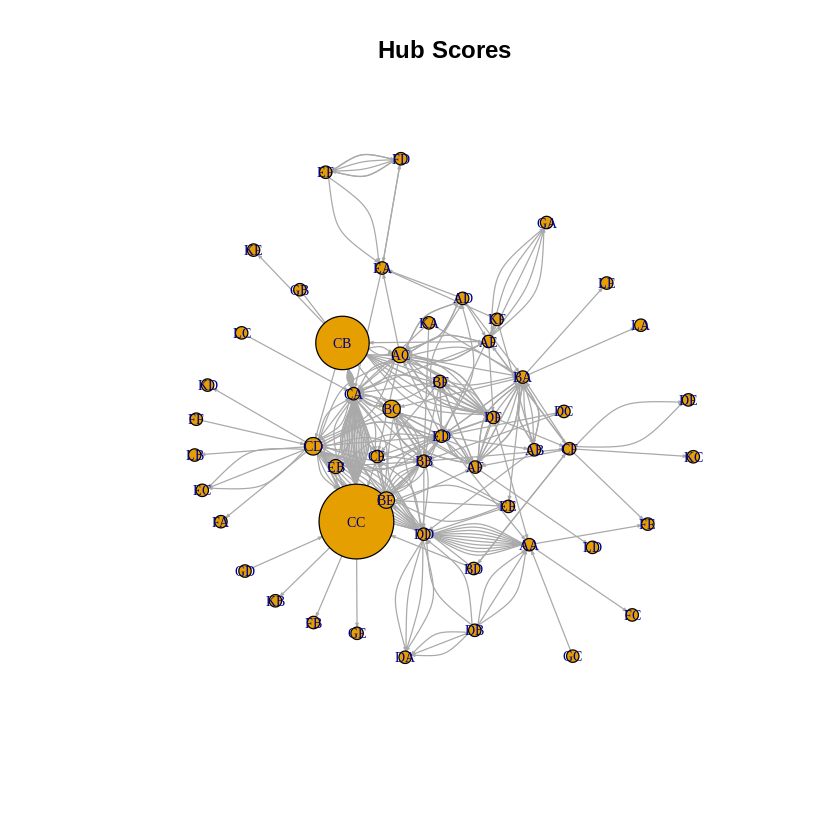

In [ ]:
set.seed(123)
layout_net <- layout_with_kk(net)

plot(
  net,
  vertex.size = pmax(5, hs * 30),
  vertex.label.cex = 0.7,
  edge.arrow.size = 0.15,
  layout = layout_net,
  main = "Hub Scores"
)


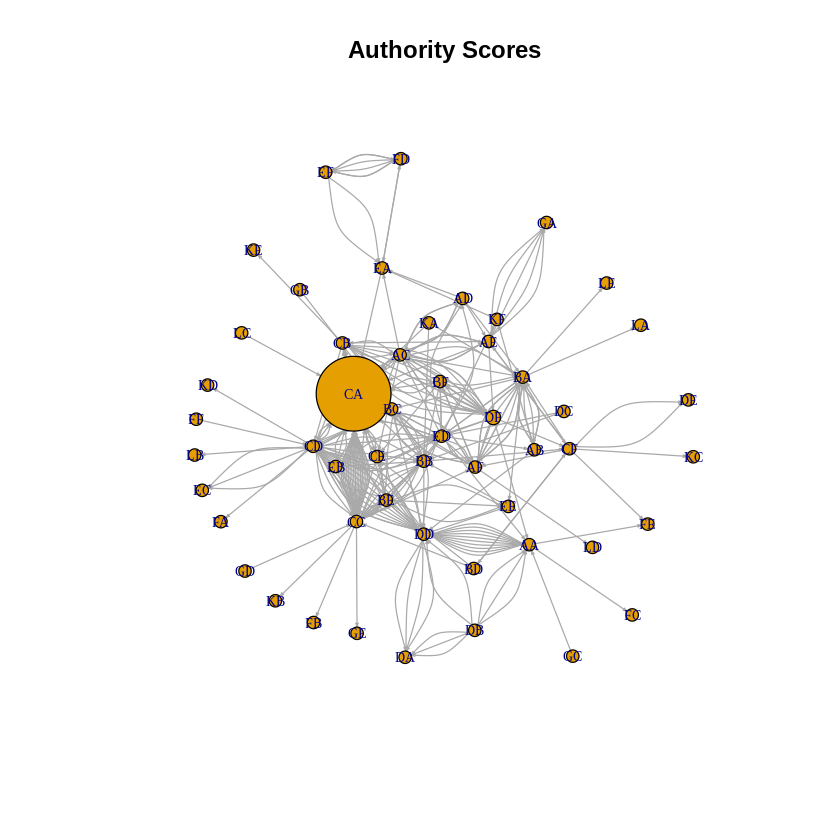

In [ ]:
set.seed(123)
plot(
  net,
  vertex.size = pmax(5, as * 30),
  vertex.label.cex = 0.7,
  edge.arrow.size = 0.15,
  layout = layout_net,
  main = "Authority Scores"
)


## 10. Community detection

For community detection, the original example converts the network to an undirected graph and applies edge-betweenness clustering.

In [ ]:
net_undirected <- as.undirected(
  net,
  mode = "collapse",
  edge.attr.comb = "first"
)

cnet <- cluster_edge_betweenness(net_undirected)

cat("Number of communities:", length(cnet), "\n")
cat("Community sizes:\n")
print(sizes(cnet))


Warning message:
“`as.undirected()` was deprecated in igraph 2.1.0.
ℹ Please use `as_undirected()` instead.”


Number of communities: 16 
Community sizes:
Community sizes
 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 
 6  1 13  6  5  5  1  4  4  1  1  1  1  1  1  1 


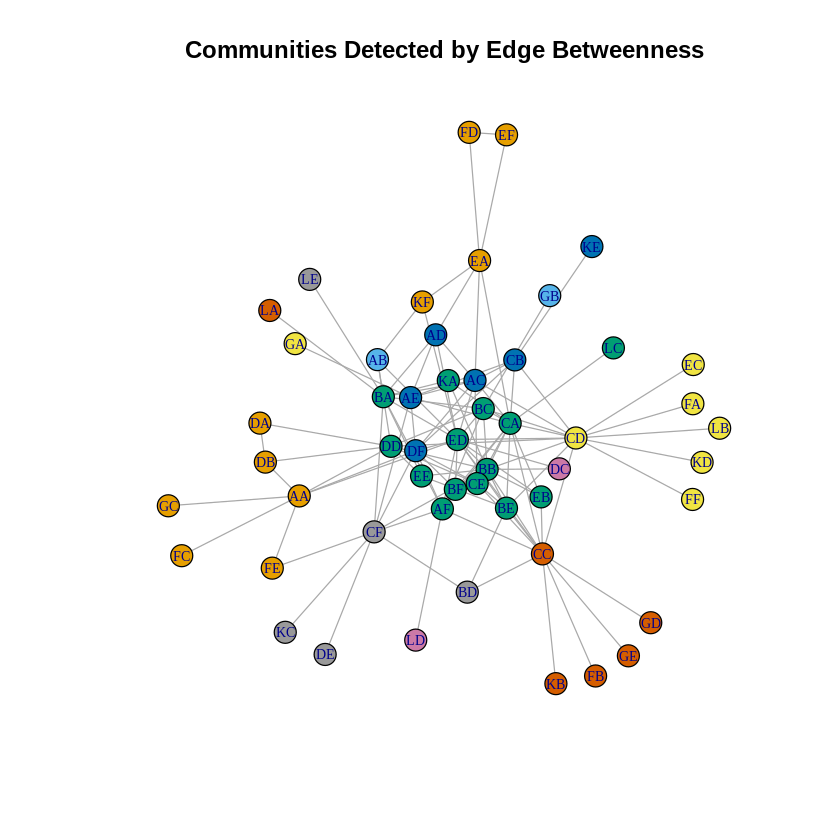

In [ ]:
set.seed(123)

plot(
  net_undirected,
  vertex.color = membership(cnet),
  vertex.size = 8,
  vertex.label.cex = 0.7,
  edge.arrow.size = 0.1,
  main = "Communities Detected by Edge Betweenness"
)

## 11. Summary of the analysis

The notebook has reproduced the main tasks from the repository example while using current `igraph` function names:

- Created directed and undirected graphs
- Calculated degree, in-degree and out-degree
- Calculated diameter and edge density
- Calculated reciprocity, closeness and betweenness
- Loaded the repository's `networkdata.csv`
- Visualized the network and degree distribution
- Calculated hub and authority scores
- Detected communities using edge betweenness
